In [2]:
#this code with reload any imports if you're updating them actively
%reload_ext autoreload
%autoreload 2
#import scipy.obinimize as obin
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
#PyGEM
import pygem_eb.input as eb_prms
import pygem.pygem_input as pygem_prms
import pygem.pygem_modelsetup as modelsetup
import class_climate

In [3]:
new_layer = pd.DataFrame([5,4,3,2,1],index=['T','w','h','t','drym'])
new_layer.loc['T']+= 4
print(new_layer.loc['T'])
a=3
surftemp = np.interp(0,[4,1],[10,5]) if a > 1 else 0
print(surftemp)
print(np.interp(0,[4,10],[0,0]))

0    9
Name: T, dtype: int64
10.0
0.0


In [4]:
if pygem_prms.glac_no not in ['01.00570'] and pygem_prms.run_eb:
    print('EB model can currently only run Gulkana glacier')
glacier_table = modelsetup.selectglaciersrgitable(pygem_prms.glac_no,
                rgi_regionsO1=pygem_prms.rgi_regionsO1, rgi_regionsO2=pygem_prms.rgi_regionsO2,
                rgi_glac_number=pygem_prms.rgi_glac_number, include_landterm=pygem_prms.include_landterm,
                include_laketerm=pygem_prms.include_laketerm, include_tidewater=pygem_prms.include_tidewater)
# ===== TIME PERIOD =====
dates_table = modelsetup.datesmodelrun(startyear=pygem_prms.gcm_startyear,endyear=pygem_prms.gcm_endyear, 
                                       spinupyears=pygem_prms.gcm_spinupyears,option_wateryear=pygem_prms.gcm_wateryear)

EB model can currently only run Gulkana glacier
1 glaciers in region 1 are included in this model run: ['00570']
This study is focusing on 1 glaciers in region [1]


In [5]:
# Automatically generate hourly (freq = 'h') dates
startdate = eb_prms.startdate
enddate = eb_prms.enddate
dates_table = pd.DataFrame({'date' : pd.date_range(startdate, enddate, freq='h')})
# Extract attributes for dates_table
dates_table['year'] = dates_table['date'].dt.year
dates_table['month'] = dates_table['date'].dt.month
dates_table['day'] = dates_table['date'].dt.day
dates_table['hour'] = dates_table['date'].dt.hour
dates_table['daysinmonth'] = dates_table['date'].dt.daysinmonth
dates_table['timestep'] = np.arange(len(dates_table['date']))
# Set date as index
dates_table.set_index('timestep', inplace=True)
# Remove leap year days if user selected this with option_leapyear
if pygem_prms.option_leapyear == 0:
    # First, change 'daysinmonth' number
    mask1 = dates_table['daysinmonth'] == 29
    dates_table.loc[mask1,'daysinmonth'] = 28
    # Next, remove the 29th days from the dates
    mask2 = ((dates_table['month'] == 2) & (dates_table['day'] == 29))
    dates_table.drop(dates_table[mask2].index, inplace=True)
    dates_table['timestep'] = np.arange(len(dates_table['date']))
    dates_table.set_index('timestep', inplace=True)

# Add column for water year
# Water year for northern hemisphere using USGS definition (October 1 - September 30th),
# e.g., water year for 2000 is from October 1, 1999 - September 30, 2000
dates_table['wateryear'] = dates_table['year']
for step in range(dates_table.shape[0]):
    if dates_table.loc[step,'month'] >= 10:
        dates_table.loc[step,'wateryear'] = dates_table.loc[step,'year'] + 1

In [6]:
gcm = class_climate.GCM(name='ERA5-hourly')
gcm_prec, gcm_hours = gcm.importGCMvarnearestneighbor_xarray(gcm.prec_fn, gcm.prec_vn, glacier_table,dates_table)
gcm_temp, gcm_hours = gcm.importGCMvarnearestneighbor_xarray(gcm.temp_fn, gcm.temp_vn, glacier_table,dates_table)
gcm_dtemp, gcm_hours = gcm.importGCMvarnearestneighbor_xarray(gcm.dtemp_fn, gcm.dtemp_vn, glacier_table,dates_table)
gcm_sp, gcm_hours = gcm.importGCMvarnearestneighbor_xarray(gcm.press_fn, gcm.press_vn, glacier_table,dates_table)
gcm_tcc, gcm_hours = gcm.importGCMvarnearestneighbor_xarray(gcm.tcc_fn, gcm.tcc_vn, glacier_table,dates_table)
gcm_surfrad, gcm_hours = gcm.importGCMvarnearestneighbor_xarray(gcm.surfrad_fn, gcm.surfrad_vn, glacier_table,dates_table) 
gcm_uwind, gcm_hours = gcm.importGCMvarnearestneighbor_xarray(gcm.uwind_fn, gcm.uwind_vn, glacier_table,dates_table)                                                      
gcm_vwind, gcm_hours = gcm.importGCMvarnearestneighbor_xarray(gcm.vwind_fn, gcm.vwind_vn, glacier_table,dates_table)

gcm_elev = gcm.importGCMfxnearestneighbor_xarray(gcm.elev_fn, gcm.elev_vn, glacier_table)

!! Not checking units for any EB variables
!! Not checking units for any EB variables
!! Not checking units for any EB variables
!! Not checking units for any EB variables
!! Not checking units for any EB variables
!! Not checking units for any EB variables


In [32]:
start = 0
end = 8791
temps = gcm_temp[0][start:end]
snow_idx = np.where(temps < 0)[0]
print(np.sum(gcm_prec[0][snow_idx]))

[   0    1    2 ... 8788 8789 8790]
0.35914455098100007


In [1]:
#ds = xr.open_dataset('/home/claire/research/Output/EB/run_2023_06_07_hourly_3yrs.nc')
ds = xr.open_dataset('/home/claire/research/Output/EB/run_2023_06_08_hourly_01.nc')

fig,axes = plt.subplots(3,3,sharex=True,sharey='row',figsize=(12,5))
nyr = 3

for bin_no in [0]:
    ds_xr = ds[['SWin','SWout','LWin','LWout','sensible','latent','rain','meltenergy','surftemp','melt','runoff','refreeze','mb']].isel(bin=bin_no)
    df = ds_xr.to_pandas()
    times = df.index
    SWnet_m = df['SWin'].resample('M').mean() + df['SWout'].resample('M').mean()
    LWnet_m = df['LWin'].resample('M').mean() + df['LWout'].resample('M').mean()
    sensible_m = df['sensible'].resample('M').mean()
    latent_m = df['latent'].resample('M').mean()
    meltenergy_m = df['meltenergy'].resample('M').mean()
    surftemp_m = df['surftemp'].resample('M').mean()
    temp_m = pd.Series(gcm_temp[0][:len(times)],pd.date_range(times[0],times[-1],freq='h')).resample('M').mean()
    melt_m = df['melt'].resample('M').sum()
    runoff_m = df['runoff'].resample('M').sum()
    refreeze_m = df['refreeze'].resample('M').sum()
    mb_m = df['mb'].resample('M').sum()

    np.mean(SWnet_m[:36].values.reshape((nyr,12)),axis=0)
    SWnet_m = np.mean(SWnet_m[:36].values.reshape((nyr,12)),axis=0)
    LWnet_m = np.mean(LWnet_m[:36].values.reshape((nyr,12)),axis=0)
    sensible_m = np.mean(sensible_m[:36].values.reshape((nyr,12)),axis=0)
    latent_m = np.mean(latent_m[:36].values.reshape((nyr,12)),axis=0)
    meltenergy_m = np.mean(meltenergy_m[:36].values.reshape((nyr,12)),axis=0)
    surftemp_m = np.mean(surftemp_m[:36].values.reshape((nyr,12)),axis=0)
    temp_m = np.mean(temp_m[:36].values.reshape((nyr,12)),axis=0)
    melt_m = np.mean(melt_m[:36].values.reshape((nyr,12)),axis=0)
    runoff_m = np.mean(runoff_m[:36].values.reshape((nyr,12)),axis=0)
    refreeze_m = np.mean(refreeze_m[:36].values.reshape((nyr,12)),axis=0)
    mb_m = np.mean(mb_m[:36].values.reshape((nyr,12)),axis=0)

    months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    plotidx = len(months)
    
    # heat fluxes
    axes[0,bin_no].plot(months,SWnet_m[:plotidx],label='netSW',linewidth=0.5)
    axes[0,bin_no].plot(months,LWnet_m[:plotidx],label='netLW',linewidth=0.5)
    axes[0,bin_no].plot(months,sensible_m[:plotidx],label='sensible',linewidth=0.5)
    axes[0,bin_no].plot(months,latent_m[:plotidx],label='latent',linewidth=0.5)
    axes[0,bin_no].plot(months,meltenergy_m[:plotidx],label='Q melt')
    axes[0,0].set_ylabel('Heat Flux ($W / m^2$)')
    # temperature
    axes[1,bin_no].plot(months,surftemp_m[:plotidx],label='surface temp')
    axes[1,bin_no].plot(months,temp_m[:plotidx],label='air temp')
    axes[1,0].set_ylabel('Temperature (C)')
    # mass balance
    axes[2,bin_no].plot(months,melt_m[:plotidx]/1000,label='melt')
    axes[2,bin_no].plot(months,runoff_m[:plotidx]/1000,label='runoff')
    axes[2,bin_no].plot(months,refreeze_m[:plotidx]/1000,label='refreeze')
    axes[2,bin_no].plot(months,mb_m[:plotidx]/1000,label='SMB')
    axes[2,0].set_ylabel('Melt/Refreeze (m w.e.)')

binname = ['Lower','Middle','Upper']
for i in range(3):
    axes[0,i].set_title(binname[i])
axes[0,0].legend(loc='upper right',bbox_to_anchor=(1.25, 1.0))
axes[1,0].legend()
axes[2,0].legend()
#plt.gcf().autofmt_xdate()
plt.show()


NameError: name 'xr' is not defined

In [42]:
import xarray as xr
ds = xr.open_dataset('/home/claire/research/climate_data/ERA5/ERA5_hourly/ERA5_precip_hourly.nc')
print(np.mean(ds['tp'].values),np.max(ds['tp'].values))
print(np.sum(ds['tp'].values[8791*2:8792*3]))

9.609986e-05 0.0048867874
0.8158159


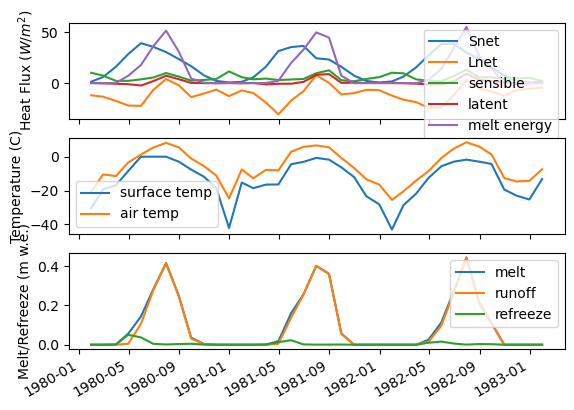

In [10]:
freq = 'W'
snow = ds['snowtemp'].sel(bin=0).to_pandas()
loop = True
i=0
while loop:
    if np.isnan(snow.iloc[i]).all:
        snow.drop(i,axis=1)
    else:
        i+=1
    if i>20:
        loop=False
print(snow)

time = ds.coords['time'].values
endtime = time[-1] +pd.Timedelta(days=5)
time = pd.date_range(time[0],endtime,freq=freq)
for i in range(len(snow.iloc[0,:])):
    if not np.all(np.isnan(snow.iloc[:,i])):
        snowdaily = snow.iloc[:,i].resample(freq).mean()
        print(min(snowdaily),max(snowdaily))
        if max(snowdaily) < 10 and min(snowdaily) > -50:
            plt.plot(time,snowdaily,label='water'+str(i))

plt.legend()
plt.show()

In [105]:
zero = np.zeros(8760)
name = '/home/claire/research/Output/EB/run_2023_06_06_hourly_00.nc'
with xr.open_dataset(name) as data:
    ds = data.load()
    ds['snowtemp'].loc[:,0] = zero
ds.to_netcdf(name)

In [107]:
precip = gcm_prec/3600
print(np.mean(gcm_prec),np.max(gcm_prec))

9.609282174515584e-05 0.004886787384748459


In [ ]:
ds = xr.open_dataset('/home/claire/research/Output/EB/run_2023_06_06_hourly_00.nc')
fig,(ax1,ax2) = plt.subplots(2,1)
end = 7000
time = ds.coords['time'][start:end]
# ax1.plot(time,ds['SWin'][start:end],label='SWin')
# ax1.plot(time,ds['SWout'][start:end],label='SWout')
ax1.plot(time,ds['SWout'][start:end]+ds['SWin'][start:end],label='Snet')
ax1.plot(time,ds['LWin'][start:end],label='LWin')
ax1.plot(time,ds['LWout'][start:end],label='LWout')
ax1.plot(time,ds['rain'][start:end],label='rain')
ax1.plot(time,ds['sensible'][start:end],label='sensible')
ax1.plot(time,ds['latent'][start:end],label='latent')
ax1.plot(time,ds['meltenergy'][start:end],label='melt E')
ax2.plot(time,ds['surftemp'][start:end],label='surftemp')
plt.gcf().autofmt_xdate()
ax1.legend()
plt.show()